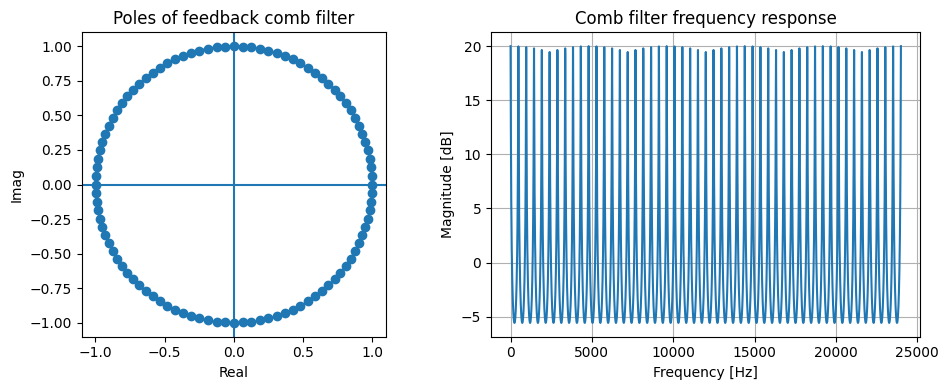

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def comb_poles(g, M):
    """Return the poles of a feedback comb filter H(z) = 1 / (1 - g z^{-M})."""
    radius = np.abs(g) ** (1.0 / M)
    ks = np.arange(M)
    angles = 2 * np.pi * ks / M
    poles = radius * np.exp(1j * angles)
    return poles

def plot_comb_example():
    Fs = 48000        # sample rate
    g = 0.9           # feedback gain
    M = 100           # delay length in samples

    poles = comb_poles(g, M)

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    # --- (1) Pole plot ---
    ax = axs[0]
    # unit circle
    theta = np.linspace(0, 2*np.pi, 512)
    unit_circle = np.exp(1j * theta)
    ax.plot(unit_circle.real, unit_circle.imag)
    ax.scatter(poles.real, poles.imag)
    ax.axhline(0)
    ax.axvline(0)
    ax.set_aspect('equal', 'box')
    ax.set_xlabel('Real')
    ax.set_ylabel('Imag')
    ax.set_title('Poles of feedback comb filter')

    # --- (2) Frequency response ---
    ax = axs[1]
    w = np.linspace(0, np.pi, 4096)          # rad/sample
    z = np.exp(1j * w)
    H = 1.0 / (1.0 - g * z ** (-M))
    mag_db = 20 * np.log10(np.maximum(np.abs(H), 1e-8))
    freqs = w / np.pi * (Fs / 2.0)

    ax.plot(freqs, mag_db)
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('Magnitude [dB]')
    ax.set_title('Comb filter frequency response')
    ax.grid(True)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_comb_example()

/var/folders/ch/6ptk_lpn2kbg9l0vj3cd2lj40000gn/T/ipykernel_21180/465001331.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  H[i] = c.conj().T @ np.linalg.inv(I - A @ D) @ b


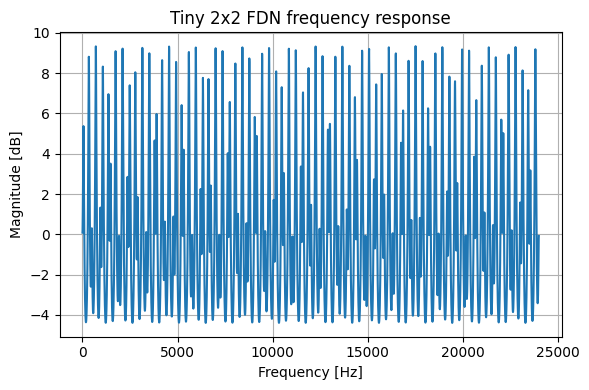

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def fdn_freq_response(A, m, b, c, Fs=48000, n_points=4096):
    """
    Compute frequency response H(e^{jw}) of an N-line FDN:
        H(z) = c^T (I - A D(z))^{-1} b,
    where D(z) = diag(z^{-m_i}).
    """
    m = np.array(m, dtype=int)
    N = len(m)
    w = np.linspace(0, np.pi, n_points)
    H = np.zeros_like(w, dtype=complex)
    I = np.eye(N, dtype=complex)

    for i, wi in enumerate(w):
        zinv = np.exp(-1j * wi)
        D = np.diag(zinv ** m)
        H[i] = c.conj().T @ np.linalg.inv(I - A @ D) @ b

    freqs = w / np.pi * (Fs / 2.0)
    return freqs, H

def plot_fdn_2x2_example():
    Fs = 48000
    # Delay lengths
    m = [100, 137]

    # Feedback matrix: scaled 2x2 Hadamard (orthogonal)
    U = (1 / np.sqrt(2)) * np.array([[1,  1],
                                     [-1, 1]], dtype=float)
    g = 0.7  # global feedback gain
    A = g * U

    N = len(m)
    # Simple input/output gains: equal into/out of all lines
    b = np.ones((N, 1)) / np.sqrt(N)
    c = np.ones((N, 1)) / np.sqrt(N)

    freqs, H = fdn_freq_response(A, m, b, c, Fs)
    mag_db = 20 * np.log10(np.maximum(np.abs(H), 1e-8))

    plt.figure(figsize=(6, 4))
    plt.plot(freqs, mag_db)
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Magnitude [dB]')
    plt.title('Tiny 2x2 FDN frequency response')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_fdn_2x2_example()


/var/folders/ch/6ptk_lpn2kbg9l0vj3cd2lj40000gn/T/ipykernel_21180/465001331.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  H[i] = c.conj().T @ np.linalg.inv(I - A @ D) @ b


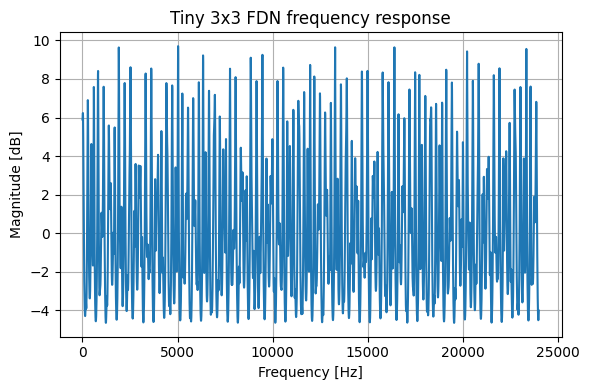

In [5]:

Fs = 48000
m = [97, 131, 173]  # three prime-ish delays

# A simple 3x3 orthogonal-ish matrix (scaled)
U = (1 / np.sqrt(3)) * np.array([[ 1,  1,  1],
                                    [ 1, -1,  1],
                                    [-1,  1,  1]], dtype=float)
g = 0.7
A = g * U

N = len(m)
b = np.ones((N, 1)) / np.sqrt(N)
c = np.ones((N, 1)) / np.sqrt(N)

freqs, H = fdn_freq_response(A, m, b, c, Fs)
mag_db = 20 * np.log10(np.maximum(np.abs(H), 1e-8))

plt.figure(figsize=(6, 4))
plt.plot(freqs, mag_db)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.title('Tiny 3x3 FDN frequency response')
plt.grid(True)
plt.tight_layout()
plt.show()
